# Training, Testing, and Accuracy


In [1]:
path_data = '../../data/'

import math
import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
def standard_units(x):
    return (x - np.mean(x))/np.std(x)

In [3]:
def distance(point1, point2):
    """The distance between two arrays of numbers."""
    return np.sqrt(np.sum((point1 - point2)**2))

def all_distances(training, point):
    """The distance between p (an array of numbers) and the numbers in row i of attribute_table."""
    attributes = training.drop(columns=['Class'])
    def distance_from_point(row):
        return distance(point, np.array(row))
    return attributes.apply(distance_from_point, axis=1)

def table_with_distances(training, point):
    """A copy of the training table with the distance from each row to array p."""
    training1 = training.copy()
    training1['Distance'] = all_distances(training1, point)
    return training1


def closest(training, point, k):
    """A table containing the k closest rows in the training table to array p."""
    with_dists = table_with_distances(training, point)
    sorted_by_distance = with_dists.sort_values(by=['Distance'])
    topk = sorted_by_distance.take(np.arange(k))
    return topk

def majority(topkclasses):
    ones = topkclasses.where('Class', are.equal_to(1)).num_rows
    zeros = topkclasses.where('Class', are.equal_to(0)).num_rows
    if ones > zeros:
        return 1
    else:
        return 0

def classify(training, p, k):
    closestk = closest(training, p, k)
    topkclasses = closestk.select('Class')
    return majority(topkclasses)

In [4]:
def classify_grid(training, test, k): 
    ckd_new1 = pd.DataFrame(columns=['Hemoglobin', 'Glucose', 'Class', 'Distance'])
    empty = np.array([])
    for i in range(len(test)):
        ckd_new2 = closest(training, np.array([test.iloc[i]]), k)
        ones = len(ckd_new2[ckd_new2['Class'] == '1'])
        zeros = len(ckd_new2[ckd_new2['Class'] == '0'])
        if ones > zeros:
            empty = np.append(empty, 1)
        else:
            empty = np.append(empty, 0)
    return empty     ### 0, 1

In [5]:
ckd = pd.read_csv(path_data + 'ckd.csv')
ckd.rename(columns={'Blood Glucose Random':'Glucose'}, inplace=True)

ckd_Standard_Unit = pd.DataFrame({
    'Hemoglobin': standard_units(ckd['Hemoglobin']), 
    'Glucose':standard_units(ckd['Glucose']), 
    'White Blood Cell Count':standard_units(ckd['White Blood Cell Count']), 
    'Class':ckd['Class'].astype(str)
})

color_table = pd.DataFrame(
    {'Class':np.array([1, 0]),
    'Color':np.array(['darkblue', 'gold'])   ### darkblue == 1
    }, index=np.array([1,0])
)
     
color_table['Class'] = color_table['Class'].astype(str)
ckd_combined = pd.merge(ckd_Standard_Unit, color_table, on='Class')
ckd_combined

,Hemoglobin,Glucose,White Blood Cell Count,Class,Color
0,-0.865744,-0.221549,-0.569768,1,darkblue
1,-1.457446,-0.947597,1.162684,1,darkblue
2,-1.004968,3.841231,-1.275582,1,darkblue
3,-2.814879,0.396364,0.809777,1,darkblue
4,-2.083954,0.643529,0.232293,1,darkblue
...,...,...,...,...,...
153,0.700526,0.133751,-0.569768,0,gold
154,0.978974,-0.870358,-0.216861,0,gold
155,0.735332,-0.484162,-0.601850,0,gold
156,0.178436,-0.267893,-0.409356,0,gold


```{contents}
:local:
:depth: 2
```


## Overly Optimistic "Testing"
The training set offers a very tempting set of patients on whom to test out our classifier, because we know the class of each patient in the training set.

But let's be careful ... there will be pitfalls ahead if we take this path. An example will show us why.

Suppose we use a 1-nearest neighbor classifier to predict whether a patient has chronic kidney disease, based on glucose and white blood cell count.

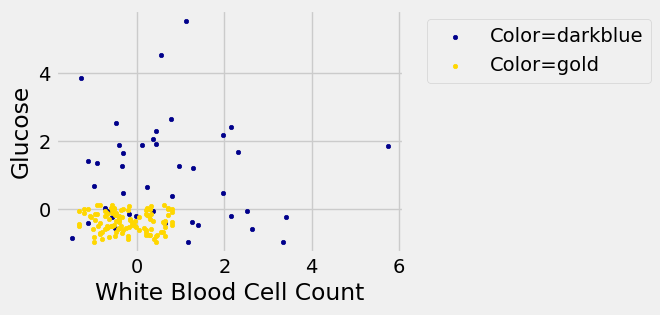

In [6]:
glucose_color_darkblue = ckd_combined[ckd_combined['Color'] == 'darkblue']
glucose_color_gold = ckd_combined[ckd_combined['Color'] == 'gold']

fig, ax = plt.subplots(figsize=(4,3))

ax.scatter(glucose_color_darkblue['White Blood Cell Count'], 
           glucose_color_darkblue['Glucose'],  
           label='Color=darkblue', 
           color='darkblue', s=10)

ax.scatter(glucose_color_gold['White Blood Cell Count'], 
           glucose_color_gold['Glucose'],  
           label='Color=gold', 
           color='gold', s=10)

x_label = 'White Blood Cell Count'
y_label = 'Glucose'
y_vals = ax.get_yticks()
plt.ylabel(y_label)
ax.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel(x_label)
plt.show()

Earlier, we said that we expect to get some classifications wrong, because there's some intermingling of blue and gold points in the lower-left.

But what about the points in the training set, that is, the points already on the scatter? Will we ever mis-classify them?

The answer is no. Remember that 1-nearest neighbor classification looks for the point *in the training set* that is nearest to the point being classified. Well, if the point being classified is already in the training set, then its nearest neighbor in the training set is itself! And therefore it will be classified as its own color, which will be correct because each point in the training set is already correctly colored.

In other words, **if we use our training set to "test" our 1-nearest neighbor classifier, the classifier will pass the test 100% of the time.**

Mission accomplished. What a great classifier! 

No, not so much. A new point in the lower-left might easily be mis-classified, as we noted earlier. "100% accuracy" was a nice dream while it lasted.

The lesson of this example is *not* to use the training set to test a classifier that is based on it.

## Generating a Test Set
In earlier chapters, we saw that random sampling could be used to estimate the proportion of individuals in a population that met some criterion.  Unfortunately, we have just seen that the training set is not like a random sample from the population of all patients, in one important respect: Our classifier guesses correctly for a higher proportion of individuals in the training set than it does for individuals in the population.

When we computed confidence intervals for numerical parameters, we wanted to have many new random samples from a population, but we only had access to a single sample.  We solved that problem by taking bootstrap resamples from our sample.

We will use an analogous idea to test our classifier. We will *create two samples out of the original training set*, use one of the samples as our training set, and *the other one for testing*. 

So we will have three groups of individuals:
- a training set on which we can do any amount of exploration to build our classifier;
- a separate testing set on which to try out our classifier and see what fraction of times it classifies correctly;
- the underlying population of individuals for whom we don't know the true classes; the hope is that our classifier will succeed about as well for these individuals as it did for our testing set.

How to generate the training and testing sets? You've guessed it – we'll select at random.

There are 158 individuals in `ckd`. Let's use a random half of them for training and the other half for testing. To do this, we'll shuffle all the rows, take the first 79 as the training set, and the remaining 79 for testing.

In [7]:
shuffled_ckd = ckd_combined.sample(len(ckd_combined), replace=False)

training = shuffled_ckd.take(np.arange(79))
testing = shuffled_ckd.take(np.arange(79, 158))

shuffled_ckd

,Hemoglobin,Glucose,White Blood Cell Count,Class,Color
98,0.143630,-0.793119,-0.216861,0,gold
133,0.004406,0.025616,0.232293,0,gold
4,-2.083954,0.643529,0.232293,1,darkblue
55,0.630914,-0.206101,-0.409356,0,gold
3,-2.814879,0.396364,0.809777,1,darkblue
...,...,...,...,...,...
85,0.074018,-0.777671,-0.505603,0,gold
145,1.048586,-0.592297,-0.730180,0,gold
112,-0.030400,-0.499610,-0.377273,0,gold
139,0.561302,-0.283341,-0.633933,0,gold


Now let's construct our classifier based on the points in the training sample:

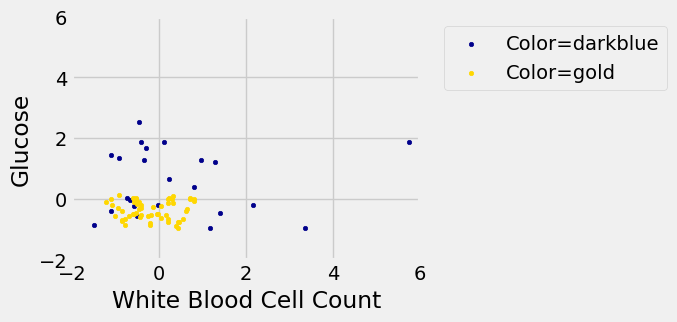

In [8]:
training_darkblue = training[training['Color'] == 'darkblue']
training_gold = training[training['Color'] == 'gold']

fig, ax = plt.subplots(figsize=(4,3))

ax.scatter(training_darkblue['White Blood Cell Count'], 
           training_darkblue['Glucose'],  
           label='Color=darkblue', 
           color='darkblue', s=10)

ax.scatter(training_gold['White Blood Cell Count'], 
           training_gold['Glucose'],  
           label='Color=gold', 
           color='gold', s=10)

x_label = 'White Blood Cell Count'
y_label = 'Glucose'
y_vals = ax.get_yticks()
plt.ylabel(y_label)
ax.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel(x_label)
plt.xlim(-2, 6)
plt.ylim(-2, 6);
plt.show()

# training.scatter('White Blood Cell Count', 'Glucose', group='Color')
# plt.xlim(-2, 6)
# plt.ylim(-2, 6);

We get the following classification regions and decision boundary:

In [9]:
x_array = np.array([])
y_array = np.array([])

for x in np.arange(-2, 6.1, 0.25):
    for y in np.arange(-2, 6.1, 0.25):
        x_array = np.append(x_array, x)
        y_array = np.append(y_array, y)
        
test_grid = pd.DataFrame({
    'Glucose': x_array,
    'White Blood Cell Count': y_array
})

In [10]:
len(test_grid)

1089

In [11]:
c_training = classify_grid(training.drop(columns=['Hemoglobin', 'Color']), test_grid, 1)

In [12]:
len(c_training)

1089

In [13]:
test_grid['Class'] = c_training.astype(int)
test_grid['Class'] = test_grid['Class'].astype(str)
test_grid

,Glucose,White Blood Cell Count,Class
0,-2.0,-2.00,1
1,-2.0,-1.75,1
2,-2.0,-1.50,1
3,-2.0,-1.25,1
4,-2.0,-1.00,0
...,...,...,...
1084,6.0,5.00,1
1085,6.0,5.25,1
1086,6.0,5.50,1
1087,6.0,5.75,1


In [14]:
test_grid_combined = test_grid[['Glucose', 'White Blood Cell Count', 'Class']].merge(color_table, on='Class')
test_grid_combined

,Glucose,White Blood Cell Count,Class,Color
0,-2.0,-2.00,1,darkblue
1,-2.0,-1.75,1,darkblue
2,-2.0,-1.50,1,darkblue
3,-2.0,-1.25,1,darkblue
4,-2.0,-1.00,0,gold
...,...,...,...,...
1084,6.0,5.00,1,darkblue
1085,6.0,5.25,1,darkblue
1086,6.0,5.50,1,darkblue
1087,6.0,5.75,1,darkblue


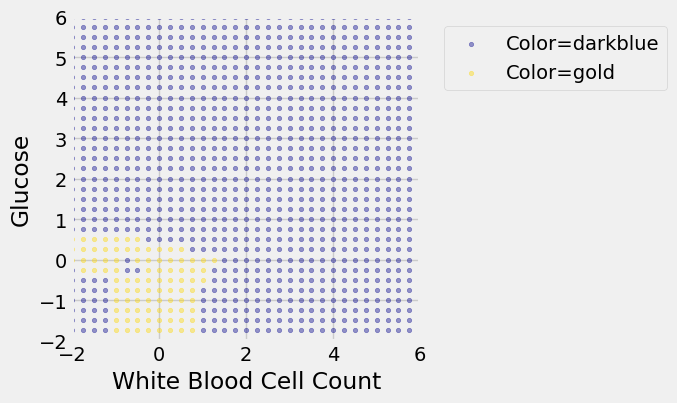

In [15]:
training_darkblue = test_grid_combined[test_grid_combined['Color'] == 'darkblue']
training_gold = test_grid_combined[test_grid_combined['Color'] == 'gold']

fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(training_darkblue['White Blood Cell Count'], training_darkblue['Glucose'],  
           label='Color=darkblue', alpha=0.4, color='darkblue', s=10)

ax.scatter(training_gold['White Blood Cell Count'], training_gold['Glucose'],  
           label='Color=gold', alpha=0.4, s=10, color='gold')

x_label = 'White Blood Cell Count'
y_label = 'Glucose'
y_vals = ax.get_yticks()
plt.ylabel(y_label)
ax.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel(x_label)
plt.xlim(-2, 6)
plt.ylim(-2, 6);
plt.show()

Place the *test* data on this graph and you can see at once that while the classifier got almost all the points right, there are some mistakes.  For example, some blue points of the test set fall in the gold region of the classifier.

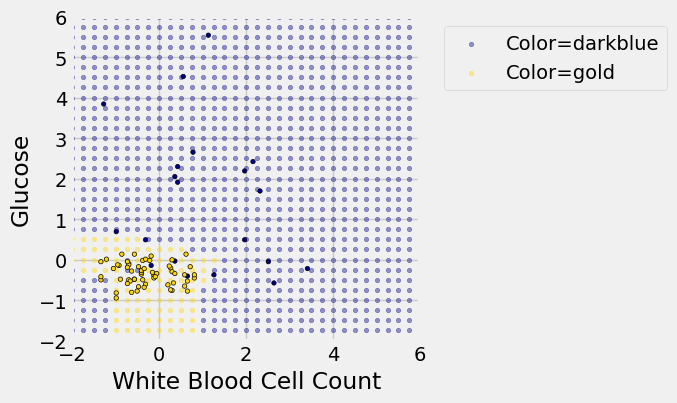

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Add predictions to grid
test_grid['Class'] = c_training
test_grid['Class'] = test_grid['Class'].astype(int)
color_table['Class'] = color_table['Class'].astype(int)

# 2. Merge with color table on Class to attach colors
test_grid = pd.merge(test_grid, color_table, on='Class', how='left')

# 3. Scatter background grid (colored prediction regions)
fig, ax = plt.subplots(figsize=(4,4))

for color, group in test_grid.groupby("Color"):
    ax.scatter(group['White Blood Cell Count'], group['Glucose'],
               color=color, alpha=0.4, s=10, label='Color='+color)

# 4. Plot actual testing points
ax.scatter(testing['White Blood Cell Count'], testing['Glucose'],
           c=testing['Color'], edgecolors='k', s=10)

# Formatting
ax.legend(bbox_to_anchor=(1.04,1), loc="upper left")
plt.xlabel("White Blood Cell Count")
plt.ylabel("Glucose")
plt.xlim(-2, 6)
plt.ylim(-2, 6)
plt.show()

Some errors notwithstanding, it looks like the classifier does fairly well on the test set. Assuming that the original sample was drawn randomly from the underlying population, the hope is that the classifier will perform with similar accuracy on the overall population, since the test set was chosen randomly from the original sample.

<!-- moved-from-1406-accuracy-of-the-classifier -->

## Classifier Accuracy


In [17]:
def distance(point1, point2):
    """Returns the distance between point1 and point2
    where each argument is an array 
    consisting of the coordinates of the point"""
    return np.sqrt(np.sum((point1 - point2)**2))

def all_distances(training, new_point):
    """Returns an array of distances
    between each point in the training set
    and the new point (which is a row of attributes)"""
    attributes = training.drop('Class')
    def distance_from_point(row):
        return distance(np.array(new_point), np.array(row))
    return attributes.apply(distance_from_point)

def table_with_distances(training, new_point):
    """Augments the training table 
    with a column of distances from new_point"""
    distances = np.sqrt(((training - new_point) ** 2).sum(axis=1))
    return training.assign(Distance=distances)

def closest(training, new_point, k):
    """Returns a table of the k rows of the augmented table
    corresponding to the k smallest distances"""
    with_dists = table_with_distances(training, new_point)
    sorted_by_distance = with_dists.sort_values('Distance')
    topk = sorted_by_distance.head(k)
    return topk

def majority(topkclasses):
    if isinstance(topkclasses, pd.DataFrame):
        classes = topkclasses['Class']
    else:
        classes = topkclasses
    # value_counts() returns counts; idxmax() gives the label with max count
    return classes.value_counts().idxmax()

def classify(training, new_point, k):
    closestk = closest(training, new_point, k)
    return majority(closestk['Class'])

In [18]:
wine = pd.read_csv(path_data + 'wine.csv')

# For converting Class to binary

def is_one(x):
    if x == 1:
        return 1
    else:
        return 0

wine['Class1'] = wine['Class'].apply(is_one)

```{contents}
:local:
:depth: 2
```


## Measuring the Accuracy of Our Wine Classifier
OK, so let's apply the hold-out method to evaluate the effectiveness of the $k$-nearest neighbor classifier for identifying wines.  The data set has 178 wines, so we'll randomly permute the data set and put 89 of them in the training set and the remaining 89 in the test set.

In [19]:
shuffled_wine = wine.sample(len(wine), replace=False) 
training_set = shuffled_wine.take(np.arange(89))
training_set.head()

,Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline,Class1
105,2,12.42,2.55,2.27,22.0,90,1.68,1.84,0.66,1.42,2.70,0.86,3.30,315,0
118,2,12.77,3.43,1.98,16.0,80,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372,0
165,3,13.73,4.36,2.26,22.5,88,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520,0
69,2,12.21,1.19,1.75,16.8,151,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718,0
22,1,13.71,1.86,2.36,16.6,101,2.61,2.88,0.27,1.69,3.80,1.11,4.00,1035,1


In [20]:
test_set  = shuffled_wine.take(np.arange(89, 178))
test_set.head()

,Class,Alcohol,Malic Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color Intensity,Hue,OD280/OD315 of diulted wines,Proline,Class1
154,3,12.58,1.29,2.10,20.0,103,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640,0
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,0
16,1,14.30,1.92,2.72,20.0,120,2.80,3.14,0.33,1.97,6.20,1.07,2.65,1280,1
60,2,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,0
40,1,13.56,1.71,2.31,16.2,117,3.15,3.29,0.34,2.34,6.13,0.95,3.38,795,1


We'll train the classifier using the 89 wines in the training set, and evaluate how well it performs on the test set. To make our lives easier, we'll write a function to evaluate a classifier on every wine in the test set:

In [21]:
def count_zero(array):
    """Counts the number of 0's in an array"""
    return len(array) - np.count_nonzero(array)

def count_equal(array1, array2):
    """Takes two numerical arrays of equal length
    and counts the indices where the two are equal"""
    return count_zero(array1 - array2)

def evaluate_accuracy(training, test, k):
    test_attributes = test.drop(columns=['Class'])
    def classify_testrow(row):
        return classify(training, row, k)
    c = test_attributes.apply(classify_testrow, axis=1)
    return count_equal(c, test['Class']) / len(test)


Now for the grand reveal -- let's see how we did.  We'll arbitrarily use $k=5$.

In [22]:
evaluate_accuracy(training_set, test_set, 5)

np.float64(0.6966292134831461)

The accuracy rate isn't bad at all for a simple classifier.

## Breast Cancer Diagnosis

Now I want to do an example based on diagnosing breast cancer.  I was inspired by Brittany Wenger, who won the Google national science fair in 2012 as a 17-year old high school student.  Here's Brittany:

![Brittany Wenger](http://i.huffpost.com/gen/701499/thumbs/o-GSF83-570.jpg?3)

Brittany's [science fair project](https://sites.google.com/a/googlesciencefair.com/science-fair-2012-project-64a91af142a459cfb486ed5cb05f803b2eb41354-1333130785-87/home) was to build a classification algorithm to diagnose breast cancer.  She won grand prize for building an algorithm whose accuracy was almost 99%. 

Let's see how well we can do, with the ideas we've learned in this course.

So, let me tell you a little bit about the data set.  Basically, if a woman has a lump in her breast, the doctors may want to take a biopsy to see if it is cancerous.  There are several different procedures for doing that.  Brittany focused on fine needle aspiration (FNA), because it is less invasive than the alternatives.  The doctor gets a sample of the mass, puts it under a microscope, takes a picture, and a trained lab tech analyzes the picture to determine whether it is cancer or not.  We get a picture like one of the following:
<!-- 
![benign](MISSING1)

![cancer](MISSING2) -->

Unfortunately, distinguishing between benign vs malignant can be tricky.  So, researchers have studied the use of machine learning to help with this task.  The idea is that we'll ask the lab tech to analyze the image and compute various attributes: things like the typical size of a cell, how much variation there is among the cell sizes, and so on.  Then, we'll try to use this information to predict (classify) whether the sample is malignant or not.  We have a training set of past samples from women where the correct diagnosis is known, and we'll hope that our machine learning algorithm can use those to learn how to predict the diagnosis for future samples.

We end up with the following data set.  For the "Class" column, 1 means malignant (cancer); 0 means benign (not cancer).

In [23]:
patients = pd.read_csv(path_data + 'breast-cancer.csv').drop(columns='ID')
patients

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,0
679,2,1,1,1,2,1,1,1,1,0
680,5,10,10,3,7,3,8,10,2,1
681,4,8,6,4,3,4,10,6,1,1


So we have 9 different attributes.  I don't know how to make a 9-dimensional scatterplot of all of them, so I'm going to pick two and plot them:

In [24]:
color_table = pd.DataFrame({
    'Class': [1, 0],
    'Color': ['darkblue', 'gold']
})
patients_with_colors = patients.merge(color_table, on='Class')


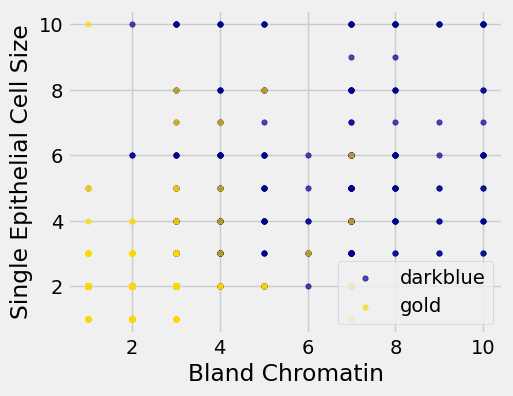

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
for color, group in patients_with_colors.groupby('Color'):
    ax.scatter(group['Bland Chromatin'], group['Single Epithelial Cell Size'],
               color=color, label=color, alpha=0.7, s=15)
ax.set_xlabel('Bland Chromatin')
ax.set_ylabel('Single Epithelial Cell Size')
ax.legend()
plt.show()


Oops.  That plot is utterly misleading, because there are a bunch of points that have identical values for both the x- and y-coordinates.  To make it easier to see all the data points, I'm going to add a little bit of random jitter to the x- and y-values.  Here's how that looks:

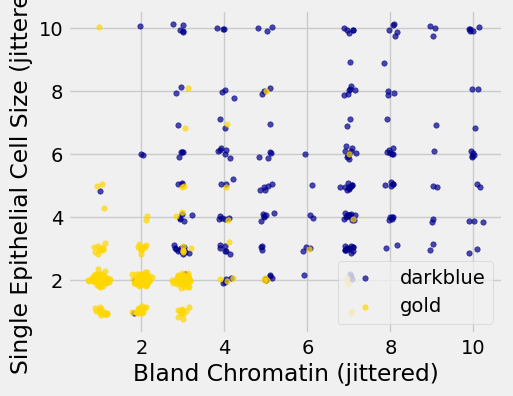

In [26]:
def randomize_column(a):
    return a + np.random.normal(0.0, 0.09, size=len(a))

jittered = patients.merge(color_table, on='Class').copy()
jittered['Bland Chromatin (jittered)'] = randomize_column(patients['Bland Chromatin'])
jittered['Single Epithelial Cell Size (jittered)'] = randomize_column(patients['Single Epithelial Cell Size'])

fig, ax = plt.subplots(figsize=(5, 4))
for color, group in jittered.groupby('Color'):
    ax.scatter(group['Bland Chromatin (jittered)'], group['Single Epithelial Cell Size (jittered)'],
               color=color, label=color, alpha=0.7, s=15)
ax.set_xlabel('Bland Chromatin (jittered)')
ax.set_ylabel('Single Epithelial Cell Size (jittered)')
ax.legend()
plt.show()


For instance, you can see there are lots of samples with chromatin = 2 and epithelial cell size = 2; all non-cancerous.

Keep in mind that the jittering is just for visualization purposes, to make it easier to get a feeling for the data.  We're ready to work with the data now, and we'll use the original (unjittered) data.

First we'll create a training set and a test set. The data set has 683 patients, so we'll randomly permute the data set and put 342 of them in the training set and the remaining 341 in the test set.

In [27]:
shuffled_patients = patients.sample(frac=1).reset_index(drop=True)
training_set = shuffled_patients.iloc[:342]
test_set  = shuffled_patients.iloc[342:]


Let's stick with 5 nearest neighbors, and see how well our classifier does.

In [28]:
evaluate_accuracy(training_set, test_set, 5)

np.float64(0.9706744868035191)

Over 96% accuracy.  Not bad!  Once again, pretty darn good for such a simple technique.

As a footnote, you might have noticed that Brittany Wenger did even better.  What techniques did she use? One key innovation is that she incorporated a confidence score into her results: her algorithm had a way to determine when it was not able to make a confident prediction, and for those patients, it didn't even try to predict their diagnosis.  Her algorithm was 99% accurate on the patients where it made a prediction -- so that extension seemed to help quite a bit.


## Section Practice

Use this short exercise to check the main workflow from this section.


In [29]:
### Exercise: Practice Training, Testing, and Accuracy
# A model produced the predictions and actual values below.
# Calculate each error as actual minus predicted. Then print the mean absolute error.
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
### Your code starts here




### Your code ends here


In [30]:
### Solution
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
errors = [a - p for a, p in zip(actual, predicted)]
mean_absolute_error = sum(abs(error) for error in errors) / len(errors)
print(errors)
print(mean_absolute_error)


[2, -3, 4, -1]
2.5
